In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, cross_val_score, validation_curve, RandomizedSearchCV, GridSearchCV
from sklearn.inspection import permutation_importance 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, plot_importance
from collections import Counter
from imblearn.metrics import classification_report_imbalanced
import math
import shap
import lime
import lime.lime_tabular


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The Count shows how many rows there are in the dataset with non-missing values.
The Std or standard deviation shows how spread out the values are
For 25%, 50%, and 75% imagine sorting the columns from smallest to lowest where the lowest is the min, the 25% is the value in the column that's > 25% and <75% of all the values in the column, the 50% is the value in the column thats > 50% and < 75% of all the values in the column.

For the parch column it seems the value 0 is > 75% of all values in the parch column so I question if parch is need to train the model. 
The Fare column's maximum value is a lot higher than the value that's > 75% of all values in the column so I wonder if the value that's the maximum for the fare column is an outlier.

In [4]:
#Show the median for Fare to determine if mean > median and if it is the data for Fare is right skewed
medi = train_data['Fare'].median()
medi

14.4542

Since the mean for the Fare column is > the median for the Fare column the data for Fare is right skewed 
so we need to apply a log transformation on it.

In [5]:
#Display the column names, how many rows in each column are not null and the data type for train data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
#Identify Categorical Features
train_data.describe(include=object).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [9]:
print("Number of values in each column that are null in train_data:", train_data.isna().sum())

Number of values in each column that are null in train_data: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


\nMissing Values in Each Column:
Age         177
Cabin       687
Embarked      2
dtype: int64


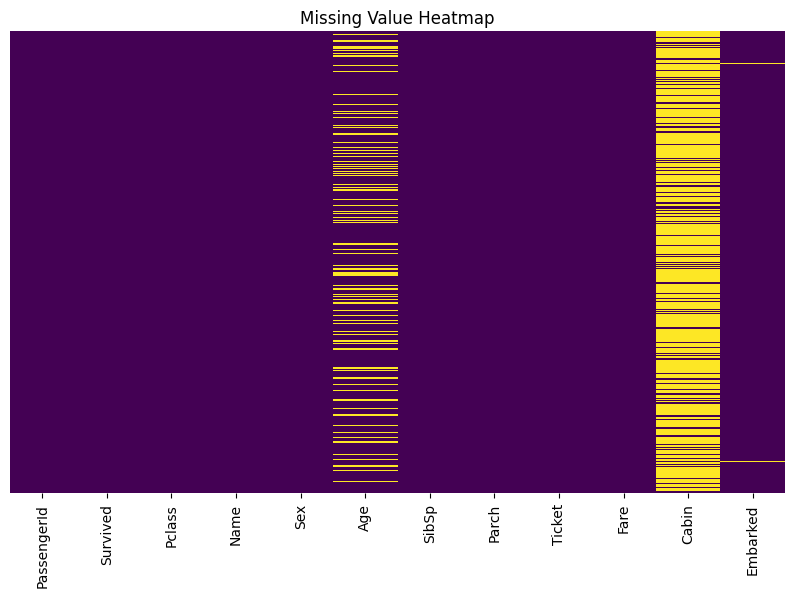

In [10]:
# Check for missing values
missing_values = train_data.isnull().sum()
print("\\nMissing Values in Each Column:")
print(missing_values[missing_values > 0])
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(train_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show() 

In [11]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
test_data.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [13]:
#Display the column names, how many rows in each column are not null and the data type for test data
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [14]:
print("Number of values in each column that are null in test data:", test_data.isna().sum())

Number of values in each column that are null in test data: PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [15]:
list(set(train_data.dtypes.tolist()))

[dtype('int64'), dtype('O'), dtype('float64')]

In [16]:
#Find the percent of samples in that survived and didn't survive in the training data to see if we maintain the 80 to 20 ratio
train_surv = train_data[train_data.Survived == 1]#Get all samples that survived
train_dsurv = train_data[train_data.Survived == 0]#Get all samples that didn't survive
print("Number of people in train_data that survived is:", len(train_surv))
print("Number of people in train_data that didn't survive is:", len(train_dsurv))
print("% of people in train_data that survived is:", len(train_surv) / len(train_data))
print("% of people in train data that didn't survive is:", len(train_dsurv) / len(train_data))

Number of people in train_data that survived is: 342
Number of people in train_data that didn't survive is: 549
% of people in train_data that survived is: 0.3838383838383838
% of people in train data that didn't survive is: 0.6161616161616161


Since the number of passengers in the data that didn't survive is higher than the number of passengers that did survive we need to do something so that the number of passengers that did survive is equal to the number of passengers that didn't survive.

Also since the number of passengers that didn't survive is higher than the number of passengers that did survive the passengers that didn't survive is the majority class/negative class and the passengers that did survive is the minority class/positive class.

In [17]:
#Check for patterns in data by seeing the percentage of men and women who survived
women = train_data.loc[train_data.Sex == 'female']["Survived"]
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_women = sum(women)/len(women)
rate_men = sum(men)/len(men)

print("% of women who survived:", rate_women)
print("% of men who survived:", rate_men)

% of women who survived: 0.7420382165605095
% of men who survived: 0.18890814558058924


Since women have a higher chance of surviving than men gender is a strong indicator of who will survive and who won't the submission file gender_submissiong.csv is not a bad first guess.

In [18]:
#Replace values in sex column from male to female to 0 and 1 where male = 0 and female = 1
train_data["Sex"] = train_data["Sex"].replace(["male", "female"], [0, 1])
test_data["Sex"] = test_data["Sex"].replace(["male", "female"], [0, 1])
test_data

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,8.0500,NaN,S


Changes the values in Sex column so that male = 0 and female = 1

In [19]:
#Combine sibsp and parch columns into relatives column since they both have to do with relatives and see if I get a better score
rel_col = train_data.SibSp + train_data.Parch
train_data.insert(8, "Relatives", rel_col, False)#set to false so we don't modify the original dataframe and cause problems
sibsp_col = test_data.SibSp
parch_col = test_data.Parch
rel_col = test_data.SibSp + test_data.Parch
test_data.insert(8, "Relatives", rel_col, False)#set to false so we don't modify the original dataframe and cause problems
#train_data.drop(train_data.loc[:, 9:11], axis=1)
#def drop_duplicate_columns(df):
    #df = df.T.drop_duplicates().T
    #return df
#train_data.drop(train_data["Relatives"], axis=1)
#test_data = drop_duplicate_columns(test_data)
print(type(train_data.SibSp))
train_data

<class 'pandas.core.series.Series'>


invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Relatives,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,1,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,1,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,1,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,3,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,0,111369,30.0000,C148,C


In [20]:
log_FaTr = np.sqrt(train_data["Fare"])
train_data.insert(11, "Log_Fare", log_FaTr, False)#set to false so we don't modify the original dataframe and cause problems
log_FaTe = np.sqrt(test_data["Fare"])
test_data.insert(10, "Log_Fare", log_FaTe, False)#set to false so we don't modify the original dataframe and cause problems
test_data

invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Relatives,Fare,Log_Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,0,7.8292,2.798071,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,1,7.0000,2.645751,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,0,9.6875,3.112475,NaN,Q
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,0,8.6625,2.943213,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2,12.2875,3.505353,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,0,8.0500,2.837252,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,0,108.9000,10.435516,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,0,7.2500,2.692582,NaN,S
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,0,8.0500,2.837252,NaN,S


In [21]:
#Create a new column called title that shows if the passenger is a mr, miss, mrs, master, etc
def get_title(name):
    if "." in name:
        return name.split(",")[1].split(".")[0].strip()
    else:
        return "Unknown"

def title_map(title):
    if title in ["Mr"]:
        return 1
    elif title in ["Master"]:
        return 3
    elif title in ["Ms", "Mlle", "Miss"]:
        return 4
    elif title in ["Mme","Mrs"]:
        return 5
    else:
        return 2

train_data["title"] = train_data["Name"].apply(get_title).apply(title_map)
test_data["title"] = test_data["Name"].apply(get_title).apply(title_map)
print(train_data["title"])
print(test_data["title"])

0      1
1      5
2      4
3      5
4      1
      ..
886    2
887    4
888    4
889    1
890    1
Name: title, Length: 891, dtype: int64
0      1
1      5
2      1
3      1
4      5
      ..
413    1
414    2
415    1
416    1
417    3
Name: title, Length: 418, dtype: int64


In [22]:
mr = train_data.loc[train_data.title == 1]["Survived"]
no_title = train_data.loc[train_data.title == 2]["Survived"]
master = train_data.loc[train_data.title == 3]["Survived"]
miss = train_data.loc[train_data.title == 4]["Survived"]
mrs = train_data.loc[train_data.title == 5]["Survived"]
rate_mr = sum(mr) / len(mr)
rate_notitle = sum(no_title) / len(no_title)
rate_master = sum(master) / len(master)
rate_miss = sum(miss) / len(miss)
rate_mrs = sum(mrs) / len(mrs)
print("% of passengers who are Mr that survived are:", rate_mr)
print("% of passengers who don't have a title that survived are:", rate_notitle)
print("% of passengers who are Master that survived are:", rate_master)
print("% of passengers who are Ms, Mlle, or Miss that survived are:", rate_miss)
print("% of passengers who are Mme or Mrs that survived are:", rate_mrs)
print("Length of mr is:", len(mr))
print("Length of no_title is:", len(no_title))
print("Length of master is:", len(master))
print("Length of miss is:", len(miss))
print("Length of mrs is:", len(mrs))

% of passengers who are Mr that survived are: 0.15667311411992263
% of passengers who don't have a title that survived are: 0.34782608695652173
% of passengers who are Master that survived are: 0.575
% of passengers who are Ms, Mlle, or Miss that survived are: 0.7027027027027027
% of passengers who are Mme or Mrs that survived are: 0.7936507936507936
Length of mr is: 517
Length of no_title is: 23
Length of master is: 40
Length of miss is: 185
Length of mrs is: 126


In [23]:
male_title = train_data.loc[(train_data.title == 2) & (train_data.Sex == 0)]["Survived"]
female_title = train_data.loc[(train_data.title == 2) & (train_data.Sex == 1)]["Survived"]
rate_mtitle = sum(male_title) / len(male_title)
rate_ftitle = sum(female_title) / len(female_title)
print("Length of male_title is:", len(male_title))
print("Length of female_title is:", len(female_title))
print("% of passengers with no title and are female who survived are:", rate_ftitle)
print("% of passengers with no title and are female who didn't survive are:", 1 - rate_ftitle)
print("% of passengers with no title and are male who survived are:", rate_mtitle)
print("% of passengers with no title and are male who didn't survive are:", 1 - rate_mtitle)

Length of male_title is: 20
Length of female_title is: 3
% of passengers with no title and are female who survived are: 1.0
% of passengers with no title and are female who didn't survive are: 0.0
% of passengers with no title and are male who survived are: 0.25
% of passengers with no title and are male who didn't survive are: 0.75


In [24]:
#Create a new column that shows women and children having priority due to chivalry
train_data["hasPriority"] = np.where(((train_data.Sex == 1) | (train_data.Age < 18)), 1, 0)#create new column in train_data called hasPriority where passengers who are female or < 18 years old have a value of 1 and all others have a value of 0
test_data["hasPriority"] = np.where(((test_data.Sex == 1) | (test_data.Age < 18)), 1, 0)#create new column in test_data called hasPriority where passengers who are female or < 18 years old have a value of 1 and all others have a value of 0
test_data

invalid value encountered in less
invalid value encountered in less
invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Relatives,Fare,Log_Fare,Cabin,Embarked,title,hasPriority
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,0,7.8292,2.798071,NaN,Q,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,1,7.0000,2.645751,NaN,S,5,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,0,9.6875,3.112475,NaN,Q,1,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,0,8.6625,2.943213,NaN,S,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2,12.2875,3.505353,NaN,S,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,0,8.0500,2.837252,NaN,S,1,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,0,108.9000,10.435516,C105,C,2,1
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,0,7.2500,2.692582,NaN,S,1,0
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,0,8.0500,2.837252,NaN,S,1,0


In [25]:
#Check for patterns in data by seeing the percentage of lower class, middle class, and upper class people who survived
low_class = train_data.loc[train_data.Pclass == 3]['Survived']
mid_class = train_data.loc[train_data.Pclass == 2]["Survived"]
up_class = train_data.loc[train_data.Pclass == 1]["Survived"]
rate_low = sum(low_class)/len(low_class)
rate_mid = sum(mid_class)/len(mid_class)
rate_up = sum(up_class)/len(up_class)

print("% of lower class who survived:", rate_low)
print("% of middle class who survived:", rate_mid)
print("% of upper class who survived:", rate_up)
test_data

% of lower class who survived: 0.24236252545824846
% of middle class who survived: 0.47282608695652173
% of upper class who survived: 0.6296296296296297


invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Relatives,Fare,Log_Fare,Cabin,Embarked,title,hasPriority
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,0,7.8292,2.798071,NaN,Q,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,1,7.0000,2.645751,NaN,S,5,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,0,9.6875,3.112475,NaN,Q,1,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,0,8.6625,2.943213,NaN,S,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2,12.2875,3.505353,NaN,S,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,0,8.0500,2.837252,NaN,S,1,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,0,108.9000,10.435516,C105,C,2,1
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,0,7.2500,2.692582,NaN,S,1,0
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,0,8.0500,2.837252,NaN,S,1,0


Based on the above it seems that upper class people have the highest chance of surviving than middle and lower class while lower class have the lowest chance of surviving.

In [26]:
#Check for patterns in data by seeing the percentage of C, Q, and S Embarked people who survived
c_embark = train_data.loc[train_data.Embarked == "C"]["Survived"]
q_embark = train_data.loc[train_data.Embarked == "Q"]["Survived"]
s_embark = train_data.loc[train_data.Embarked == "S"]["Survived"]
rate_c = sum(c_embark) / len(c_embark)
rate_q = sum(q_embark) / len(q_embark)
rate_s = sum(s_embark) / len(s_embark)
print("% of C embarked people who survived:", rate_c)
print("% of Q embarked people who survived:", rate_q)
print("% of S embarked people who survived:", rate_s)

% of C embarked people who survived: 0.5535714285714286
% of Q embarked people who survived: 0.38961038961038963
% of S embarked people who survived: 0.33695652173913043


Based on the above it seems that the people who embarked from C have a higher chance of surviving than the people who embarked from Q and S. While the people who embarked from S have the lowest chance of surviving.

In [27]:
#Create a new column that shows if the passenger can swim or not
swim_age = train_data[train_data.Survived == 1]["Age"].max()
low_swim_age = train_data[train_data.Survived == 1]["Age"].min()
print("The highest age you can swim and survive is:", swim_age)
print("The lowest age you can swim and survive is:", low_swim_age)
print(train_data[train_data.Age == 0.42])
old = train_data.loc[train_data.Age > 60]

The highest age you can swim and survive is: 80.0
The lowest age you can swim and survive is: 0.42
     PassengerId  Survived  Pclass                             Name  Sex  \
803          804         1       3  Thomas, Master. Assad Alexander    0   

      Age  SibSp  Parch  Relatives Ticket    Fare  Log_Fare Cabin Embarked  \
803  0.42      0      1          1   2625  8.5167  2.918339   NaN        C   

     title  hasPriority  
803      3            1  


invalid value encountered in greater


In [28]:
#Check for patterns in data by seeing the percentage of people who are below 40 years old and above 40 years old who survived
print("The median of column Age is: ", train_data.Age.median())
young = train_data.loc[train_data.Age < 28]['Survived']
old = train_data.loc[train_data.Age > 28]["Survived"]
rate_young = sum(young)/len(young)
rate_old = sum(old)/len(old)

print("% of young passengers who survived:", rate_young)
print("% of old passengers who survived:", rate_old)

The median of column Age is:  28.0
% of young passengers who survived: 0.41839762611275966
% of old passengers who survived: 0.4034090909090909


invalid value encountered in less


Age doesn't influence the survival of the passengers much since the percent of young and old passengers surviving is almost equal so me don't need to include that in training the model

In [29]:
#Replace all nan values in fare column for training and test data with median value
fare_median = np.nanmedian(train_data.Fare)
train_data.Fare.fillna(fare_median, inplace=True)
fare_median2 = np.nanmedian(test_data.Fare)
test_data.Fare.fillna(fare_median2, inplace=True)
test_data

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


invali

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Relatives,Fare,Log_Fare,Cabin,Embarked,title,hasPriority
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,0,7.8292,2.798071,NaN,Q,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,1,7.0000,2.645751,NaN,S,5,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,0,9.6875,3.112475,NaN,Q,1,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,0,8.6625,2.943213,NaN,S,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2,12.2875,3.505353,NaN,S,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,0,8.0500,2.837252,NaN,S,1,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,0,108.9000,10.435516,C105,C,2,1
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,0,7.2500,2.692582,NaN,S,1,0
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,0,8.0500,2.837252,NaN,S,1,0


In [30]:
#Replace all nan values in Log_Fare column for training and test data with median value
fare_median = np.nanmedian(train_data.Log_Fare)
train_data.Log_Fare.fillna(fare_median, inplace=True)
fare_median2 = np.nanmedian(test_data.Log_Fare)
test_data.Log_Fare.fillna(fare_median2, inplace=True)
test_data

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


invali

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Relatives,Fare,Log_Fare,Cabin,Embarked,title,hasPriority
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,0,7.8292,2.798071,NaN,Q,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,1,7.0000,2.645751,NaN,S,5,1
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,0,9.6875,3.112475,NaN,Q,1,0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,0,8.6625,2.943213,NaN,S,1,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,2,12.2875,3.505353,NaN,S,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,0,8.0500,2.837252,NaN,S,1,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,0,108.9000,10.435516,C105,C,2,1
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,0,7.2500,2.692582,NaN,S,1,0
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,0,8.0500,2.837252,NaN,S,1,0


In [31]:
survive_mean = train_data.loc[train_data.Survived == 1]["PassengerId"].mean()#Get the mean value of passengerID for all passengers with Survived == 1
nosurv_mean = train_data.loc[train_data.Survived == 0]["PassengerId"].mean()#Get the mean value of passengerID for all passengers with Survived == 0
print("Value of survive_mean is:", survive_mean)
print("Value of nosurv_mean is:", nosurv_mean)

Value of survive_mean is: 444.36842105263156
Value of nosurv_mean is: 447.0163934426229


In [32]:
#train_data1 = train_data.drop(columns=["Name", "Sex", "Relatives", "Ticket", "Cabin", "Lifeboat_Dist", "Embarked"])
train_data1 = train_data.drop(columns=["Name", "Sex", "Relatives", "Ticket", "Cabin", "Embarked"])
print("Value of train_data.groupby survived is:", train_data1.groupby("Survived"))
ab = train_data1.groupby("Survived").mean()#Get the mean value of each column for all passengers with Survived == 1 and Survived == 0 separately
print("Value of ab is:", ab)
v1 = ab.iloc[0,:]#Assign the mean value of each column for all passengers with Survive == 0 to the variable v1
v2 = ab.iloc[1,:]#Assign the mean value of each column for all passengers with Survive == 1 to the variable v2
print("Value of v1 is:", v1)
print("Value of v2 is:", v2)
abs((v2-v1)/(v1+v2))#Calculate the relative difference between the columns with Survive == 1 and Survive == 0

Value of train_data.groupby survived is: <pandas.core.groupby.generic.DataFrameGroupBy object at 0x7b3e142aa920>
Value of ab is:           PassengerId    Pclass        Age     SibSp     Parch       Fare  \
Survived                                                                    
0          447.016393  2.531876  30.626179  0.553734  0.329690  22.117887   
1          444.368421  1.950292  28.343690  0.473684  0.464912  48.395408   

          Log_Fare     title  hasPriority  
Survived                                   
0         4.124956  1.579235     0.211293  
1         6.017064  3.467836     0.748538  
Value of v1 is: PassengerId    447.016393
Pclass           2.531876
Age             30.626179
SibSp            0.553734
Parch            0.329690
Fare            22.117887
Log_Fare         4.124956
title            1.579235
hasPriority      0.211293
Name: 0, dtype: float64
Value of v2 is: PassengerId    444.368421
Pclass           1.950292
Age             28.343690
SibSp            0

PassengerId    0.002971
Pclass         0.129755
Age            0.038706
SibSp          0.077914
Parch          0.170176
Fare           0.372661
Log_Fare       0.186561
title          0.374197
hasPriority    0.559728
dtype: float64

<Axes: >

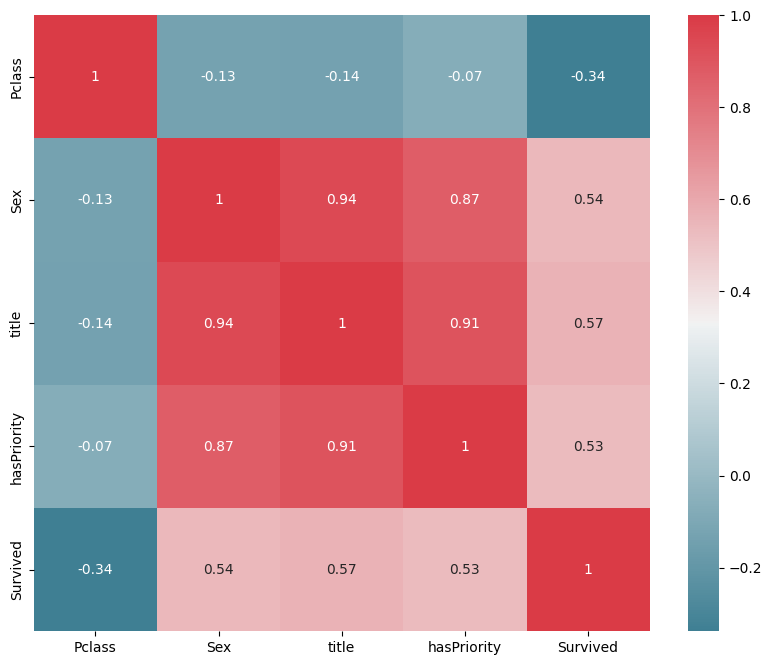

In [33]:
#Plot a heatmap of the correlation (how strong a relationship between 2 variables are and their direction) between all features
y = train_data["Survived"].astype(int)#get the true label y from the training data 

features = ["Pclass", "Sex", "title", "hasPriority"]#Chose the square root of number of features to train our model on
X = pd.get_dummies(train_data[features])#extract all values in Pclass, Sex, Sibsp, and parch columns for training the model
X_test = pd.get_dummies(test_data[features])#extract the values from columns contained ifeature_importances_y
f, ax = plt.subplots(figsize=(10,8))
data = pd.concat([X, y], axis=1)
corr = data.corr()
sns.heatmap(corr, mask=np.zeros_like(corr), annot=True, cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True)

Since Fare, Sex_Female, and Embarked_C are positively correlated with target variable survived they will be useful in predicting the target variable because for positive correlations as one variable increases the other will increase as well. Also since Pclass, Sex_male, and Embarked_S are negatively correlated with the target variable they will also be useful in predicting the target but in the opposite direction because for negatively correlated features as one variable increases the other decreases. 

Since high fare passengers have a higher chance of surviving than low fare passengers we should include that in the model training.

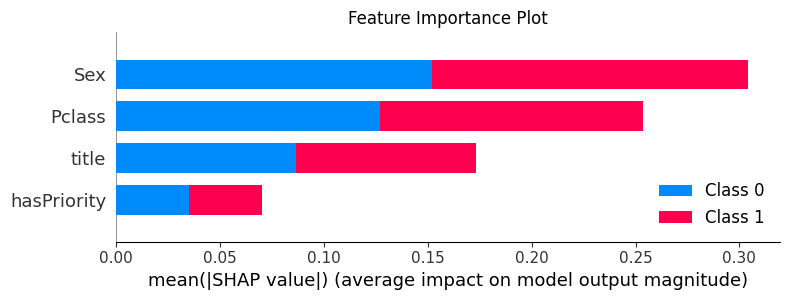

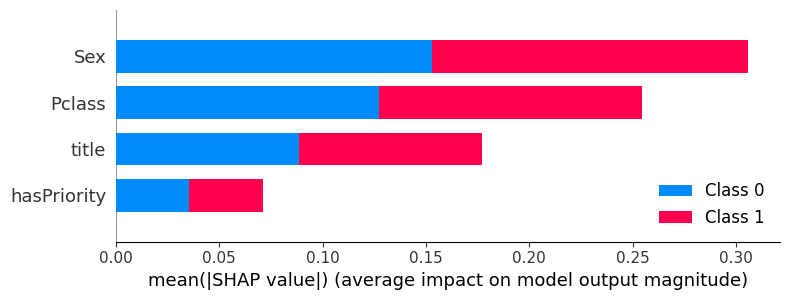

In [34]:
# Calculate feature importance using SHAP
model = RandomForestClassifier(n_estimators=9, max_depth=4, random_state=1)
model.fit(X, y)
explainer = shap.TreeExplainer(model)
train_shap = explainer.shap_values(X)
test_shap = explainer.shap_values(X_test)
figure = plt.figure()
plt.title("Feature Importance Plot")
shap.summary_plot(train_shap, X)
shap.summary_plot(test_shap, X_test)

Class 1 represents survived and class 0 represents didn't survive
It also seems that the most important features the model uses to make predictions are title, sex, fare, and Pclass

Since the specificity (specificity = # of samples correctly classified as negative/total number of negative samples) is high the model is good at predicting the negative class.

In [35]:
model = RandomForestClassifier(n_estimators=82, max_depth=4, max_features=None, min_samples_split=5, random_state=1)
model.fit(X, y)#train the model on x training data
train_acc = model.score(X, y)
print("Training accuracy of model is:", train_acc)
predictions = model.predict(X_test)#test the model on the test data
#explainer = lime.lime_tabular.LimeTabularExplainer(X.values, feature_names=X.columns.values.tolist(), class_names=["not_survived", "Survived"], verbose=True, mode='classification')
#j = 5
#exp = explainer.explain_instance(X_test.values[j], model.predict, num_features=6)
#print("Survived:", sum(predictions == 1))
#print("Didn't Survive", sum(predictions == 0))
#model = MLPClassifier(hidden_layer_sizes=(3, 7), activation='relu', solver='lbfgs', random_state=1)
#model.fit(X, y)
#predictions = model.predict(X_test)

#base_learners = []
#log_reg = LogisticRegression(solver='liblinear', random_state=1)
#base_learners.append(log_reg)
#tree = DecisionTreeClassifier(max_depth=3, random_state=1)#start out with a tree with a 2 or 3 depth and see how increasing or decreasing the depth affects performance
#base_learners.append(tree)
#meta_data = np.zeros((len(base_learners), len(X)))#Variable to store metadata and has len(base_learner) rows and len(X) columns
#Kfold = KFold(n_splits=5)#Create the KFold Cross Validation and set the number of folds to 5
#meta_index = 0#Used to keep track of where the predictions for each fold should be stored in meta_data and meta_targets

#log_reg.fit(X, y)
#predictions = log_reg.predict(X_test)

#models = [
 #   LogisticRegression(C=0.01)#regularization parameter of 0.01 is a good starting value
  #  SVC(C=0.01)
#]

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})#create a dataset that contains the output from model predicting if passenger from test data survived
output.to_csv('submission.csv', index=False)#name the output dataset submission.csv and save it
print("Your submission was successfully saved!")

Training accuracy of model is: 0.8013468013468014
Your submission was successfully saved!
